# Advanced Matplotlib Layouts & Annotations: Beginner Guide

### 📌 Overview
Master **Advanced Matplotlib Layouts & Annotations: Beginner Guide** with concise, zero-fluff bullet points and executable code on real Fintech records ([raw_transactions.csv](file:///data/raw_transactions.csv)).

### 📚 Key Concepts Covered in this Notebook:
- **Multi-Panel Layouts**: Covers `plt.subplots(nrows, ncols)`, `fig.add_subplot()`, and `matplotlib.gridspec.GridSpec`.
- **Secondary Axes**: Covers `ax.twinx()`.
- **Visual Annotations**: Covers `ax.annotate()` with arrowprops and `ax.text()`.
- **Custom Vector Patches**: Covers `Rectangle`, `Circle`, `Polygon`, and `FancyArrowPatch`.
- **Styling Controls**: Covers `ax.set_facecolor()`, `ax.spines['right'].set_visible(False)`, `plt.style.use()`, and `fig.tight_layout()`.


In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

# Configure visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")
print(df.head(2))

Loaded 14251 cleaned transaction records from ../data/raw_transactions.csv
  transaction_id customer_id merchant_id  transaction_amount card_type  \
0       TX109326      C55082       M3549              607.78      Visa   
1       TX106376      C76616       M3068             1819.11      Visa   

  transaction_status device_type  account_age_months    transaction_date  \
0           Reversed      Mobile                   8 2026-02-17 08:28:57   
1            Pending         POS                  28 2025-01-03 00:00:00   

  region  is_fraud  
0  North         0  
1   West         1  


### 🔹 Multi-Panel Grids: `plt.subplots(nrows, ncols)`
- **What it does:** Generates 2x2 multi-panel layout matrix returning array of Axes.
- **Syntax:** `fig, axes = plt.subplots(2, 2, figsize=(10, 8))`
- **Operation:** `fig, axes = plt.subplots(2, 2, figsize=(8, 6))`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

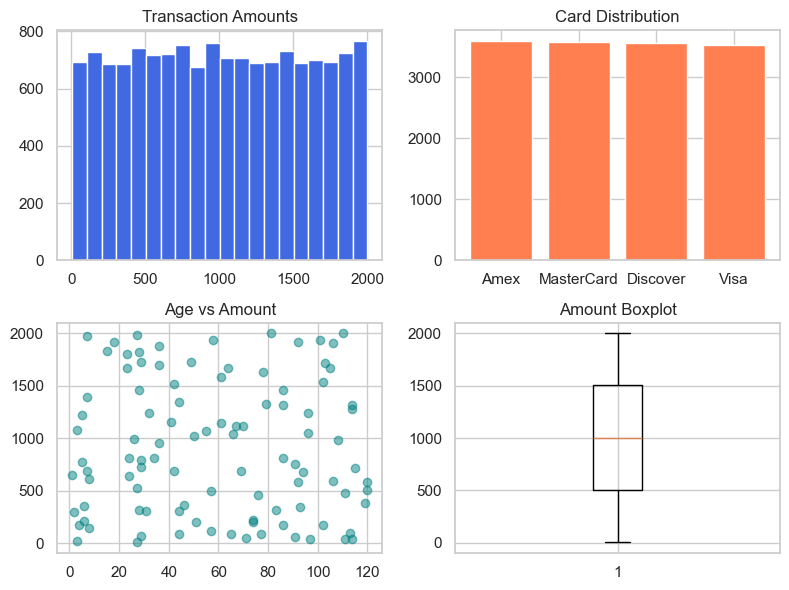

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].hist(df['transaction_amount'], bins=20, color='royalblue')
axes[0, 0].set_title('Transaction Amounts')
axes[0, 1].bar(df['card_type'].value_counts().index, df['card_type'].value_counts().values, color='coral')
axes[0, 1].set_title('Card Distribution')
axes[1, 0].scatter(df['account_age_months'].head(100), df['transaction_amount'].head(100), alpha=0.5, color='teal')
axes[1, 0].set_title('Age vs Amount')
axes[1, 1].boxplot(df['transaction_amount'].dropna())
axes[1, 1].set_title('Amount Boxplot')
plt.tight_layout()
plt.show()

### 🔹 Manual Panel Placement: `fig.add_subplot()`
- **What it does:** Manually attaches Axes to arbitrary grid coordinates on canvas.
- **Syntax:** `ax = fig.add_subplot(2, 1, 1)`
- **Operation:** `fig = plt.figure(figsize=(8, 4))`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

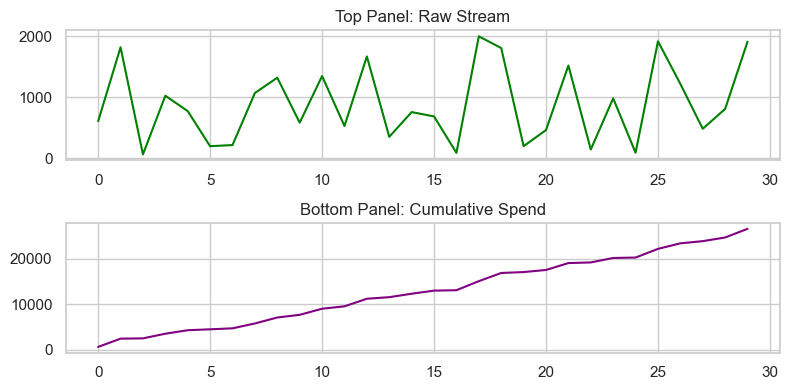

In [3]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(df['transaction_amount'].head(30), color='green')
ax1.set_title('Top Panel: Raw Stream')
ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(df['transaction_amount'].head(30).cumsum(), color='purple')
ax2.set_title('Bottom Panel: Cumulative Spend')
plt.tight_layout()
plt.show()

### 🔹 Flexible Grid Layouts: `matplotlib.gridspec.GridSpec`
- **What it does:** Constructs complex multi-row and multi-column spanning layouts.
- **Syntax:** `gs = GridSpec(3, 3, figure=fig); ax = fig.add_subplot(gs[0, :])`
- **Operation:** `from matplotlib.gridspec import GridSpec`
- **Key Note:** Always provide clear axis labels (`xlabel`, `ylabel`) and a title so viewers can interpret your visualization at a glance.

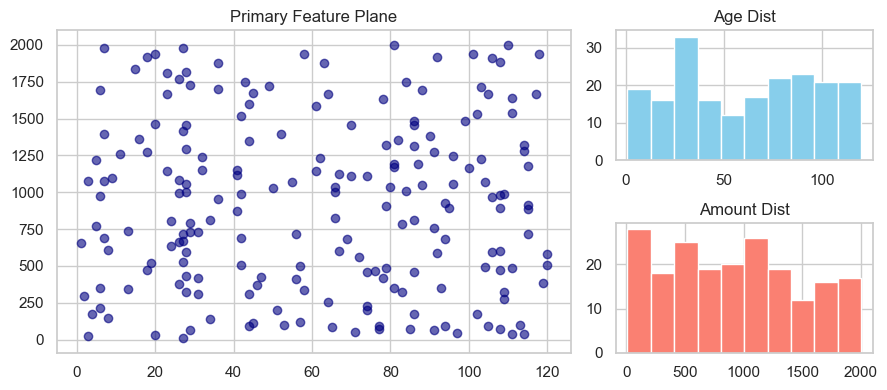

In [4]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(9, 4))
gs = GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])
ax_main = fig.add_subplot(gs[:, 0])
ax_main.scatter(df['account_age_months'].head(200), df['transaction_amount'].head(200), alpha=0.6, color='navy')
ax_main.set_title('Primary Feature Plane')
ax_side1 = fig.add_subplot(gs[0, 1])
ax_side1.hist(df['account_age_months'].head(200), color='skyblue')
ax_side1.set_title('Age Dist')
ax_side2 = fig.add_subplot(gs[1, 1])
ax_side2.hist(df['transaction_amount'].head(200), color='salmon')
ax_side2.set_title('Amount Dist')
plt.tight_layout()
plt.show()

### 🔹 Secondary Dual-Scale Axes: `ax.twinx()`
- **What it does:** Overlays two independent metrics sharing the x-axis with different y-axis scales (e.g.
- **Syntax:** `ax2 = ax1.twinx()`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

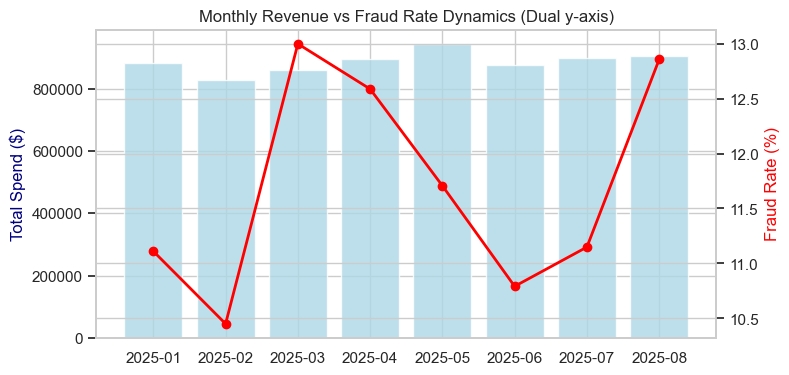

In [5]:
monthly = df.set_index('transaction_date').resample('ME').agg({'transaction_amount': 'sum', 'is_fraud': 'mean'}).head(8)
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.bar(monthly.index.strftime('%Y-%m'), monthly['transaction_amount'], color='lightblue', label='Revenue ($)', alpha=0.8)
ax2.plot(monthly.index.strftime('%Y-%m'), monthly['is_fraud'] * 100, color='red', marker='o', lw=2, label='Fraud Rate (%)')
ax1.set_ylabel('Total Spend ($)', color='navy')
ax2.set_ylabel('Fraud Rate (%)', color='red')
ax1.set_title('Monthly Revenue vs Fraud Rate Dynamics (Dual y-axis)')
plt.show()

### 🔹 Visual Annotations: `ax.annotate(arrowprops=...)`
- **What it does:** Points callout arrows to specific data points (e.g., peak revenue anomalies).
- **Syntax:** `ax.annotate('Anomaly', xy=(x, y), xytext=(x+1, y+10), arrowprops=dict(facecolor='black'))`
- **Operation:** `top_tx = df.sort_values(by='transaction_amount', ascending=False).iloc[0]`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

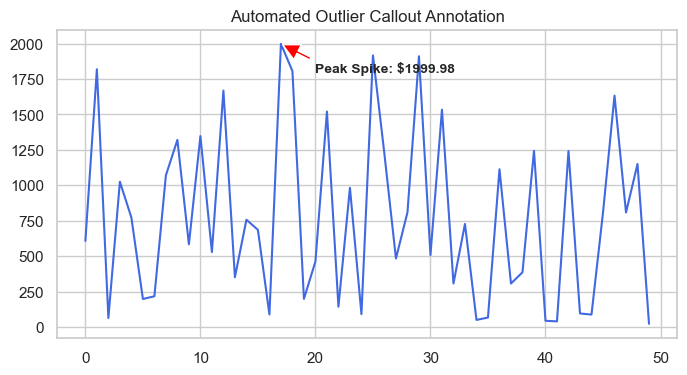

In [6]:
top_tx = df.sort_values(by='transaction_amount', ascending=False).iloc[0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['transaction_amount'].head(50), color='royalblue')
max_idx = df['transaction_amount'].head(50).argmax()
ax.annotate(f'Peak Spike: ${top_tx["transaction_amount"]:.2f}', xy=(max_idx, df['transaction_amount'].iloc[max_idx]), xytext=(max_idx+3, df['transaction_amount'].iloc[max_idx]-200), arrowprops=dict(facecolor='red', shrink=0.05, width=2), fontsize=10, fontweight='bold')
ax.set_title('Automated Outlier Callout Annotation')
plt.show()

### 🔹 Text Placement: `ax.text()`
- **What it does:** Draws informational summary text directly on canvas coordinates.
- **Syntax:** `ax.text(x, y, 'Summary Note', fontsize=12)`
- **Operation:** `fig, ax = plt.subplots(figsize=(8, 3))`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

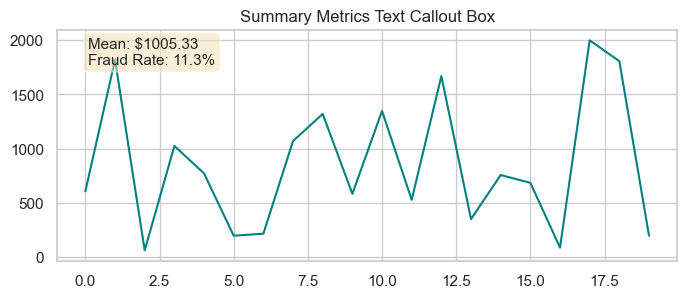

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df['transaction_amount'].head(20), color='teal')
ax.text(0.05, 0.85, f'Mean: ${df["transaction_amount"].mean():.2f}\nFraud Rate: {df["is_fraud"].mean()*100:.1f}%', transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=11)
ax.set_title('Summary Metrics Text Callout Box')
plt.show()

### 🔹 Vector Patches: `Rectangle` & `Circle`
- **What it does:** Draws geometric shapes highlighting critical risk zones.
- **Syntax:** `ax.add_patch(Rectangle((x, y), width, height, fill=False))`
- **Operation:** `from matplotlib.patches import Rectangle, Circle`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

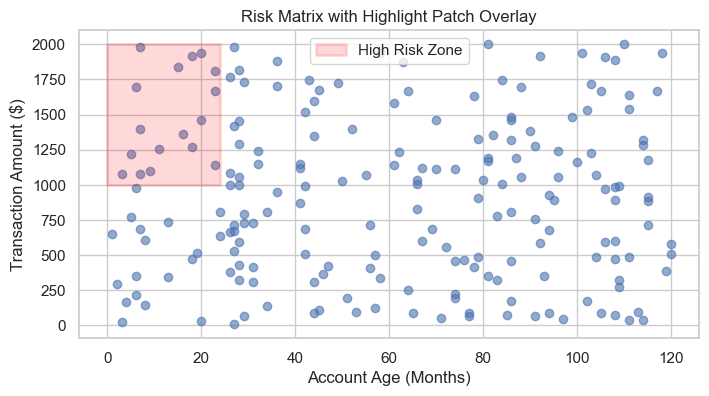

In [8]:
from matplotlib.patches import Rectangle, Circle
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['account_age_months'].head(200), df['transaction_amount'].head(200), alpha=0.6)
# Highlight high risk zone (age < 12 months & amount > 1000)
rect = Rectangle((0, 1000), 24, 1000, linewidth=2, edgecolor='red', facecolor='red', alpha=0.15, label='High Risk Zone')
ax.add_patch(rect)
ax.set_title('Risk Matrix with Highlight Patch Overlay')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
ax.legend()
plt.show()

### 🔹 Canvas Styling: `ax.set_facecolor()`
- **What it does:** Customizes plot area background color.
- **Syntax:** `ax.set_facecolor('#f4f4f4')`
- **Operation:** `fig, ax = plt.subplots(figsize=(7, 3))`
- **Key Note:** Sets only store unique elements and provide $O(1)$ instant lookup time, making `item in my_set` extremely fast.

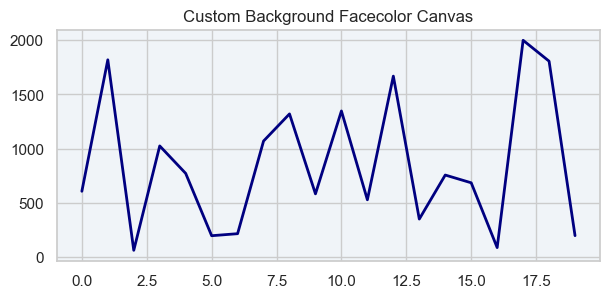

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.set_facecolor('#f0f4f8')
ax.plot(df['transaction_amount'].head(20), color='navy', lw=2)
ax.set_title('Custom Background Facecolor Canvas')
plt.show()

### 🔹 Spine Customization: `ax.spines`
- **What it does:** Hides top and right chart borders for clean minimalist presentation.
- **Syntax:** `ax.spines['top'].set_visible(False)`
- **Operation:** `fig, ax = plt.subplots(figsize=(7, 3))`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

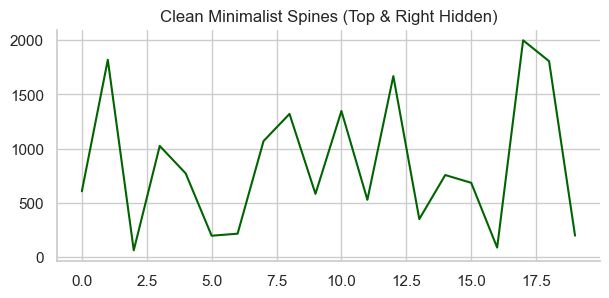

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df['transaction_amount'].head(20), color='darkgreen')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Clean Minimalist Spines (Top & Right Hidden)')
plt.show()

### 🔹 Style Sheets: `plt.style.use()`
- **What it does:** Applies pre-defined visual style sheets (e.g.
- **Syntax:** `plt.style.use('ggplot')`
- **Operation:** `plt.style.use('ggplot')`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

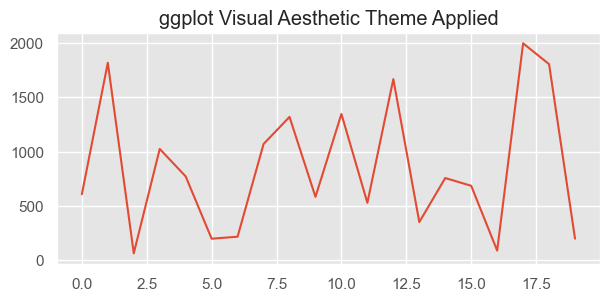

In [11]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df['transaction_amount'].head(20))
ax.set_title('ggplot Visual Aesthetic Theme Applied')
plt.show()
plt.style.use('default')

### 🔹 Preventing Clipped Labels: `fig.tight_layout()`
- **What it does:** Automatically adjusts subplot padding to prevent labels and titles from overlapping.
- **Syntax:** `fig.tight_layout()`
- **Operation:** `fig, ax = plt.subplots(figsize=(7, 3))`
- **Key Note:** Test operations on a small sample of your dataset first (`df.head()` or `[:5]`) before running across all rows.

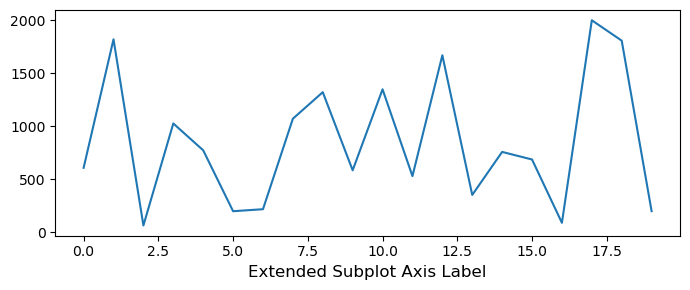

In [12]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df['transaction_amount'].head(20))
ax.set_xlabel('Extended Subplot Axis Label', fontsize=12)
fig.tight_layout()
plt.show()

## 💡 Real-World Practice & Scenarios
Practical scenarios and common data engineering questions explained with real examples.


### 🔍 Scenario: Q1: Coordinate Transformation Pipelines in Matplotlib
- **Objective:** Q1: Coordinate Transformation Pipelines in Matplotlib
- **Approach:** Explain differences between Data Coordinates (`ax.transData`), Axes Coordinates (`ax.transAxes`), and Figure Coordinates (`fig.transFigure`).
- **Syntax:** `transform=ax.transAxes` (0 to 1)

In [13]:
print('transData: Positioned relative to data values. transAxes: (0,0) bottom-left to (1,1) top-right of Axes.')

transData: Positioned relative to data values. transAxes: (0,0) bottom-left to (1,1) top-right of Axes.
